### Importing required dependencies:

In [67]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import cross_val_score , train_test_split
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

### loading dataset:

In [68]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [69]:
# just for our required features extracted
df = df[['survived', 'fare', 'age']]
df.head()

,survived,fare,age
0,0,7.2500,22.0
1,1,71.2833,38.0
2,1,7.9250,26.0
3,1,53.1000,35.0
4,0,8.0500,35.0


In [70]:
# to see the missing value in our dataset
df.isnull().sum()

survived      0
fare          0
age         177
dtype: int64

In [71]:
# fill the missing values of age column
df['age'] = df['age'].fillna(df['age'].mean())

In [72]:
df.isnull().sum()

survived    0
fare        0
age         0
dtype: int64

In [73]:
# first spiriting our dataset
x = df.drop('survived', axis = 1)
y = df['survived']

In [45]:
x.shape

(891, 2)

In [46]:
y.shape

(891,)

In [74]:
# train test spliting 

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.20, random_state = 42)

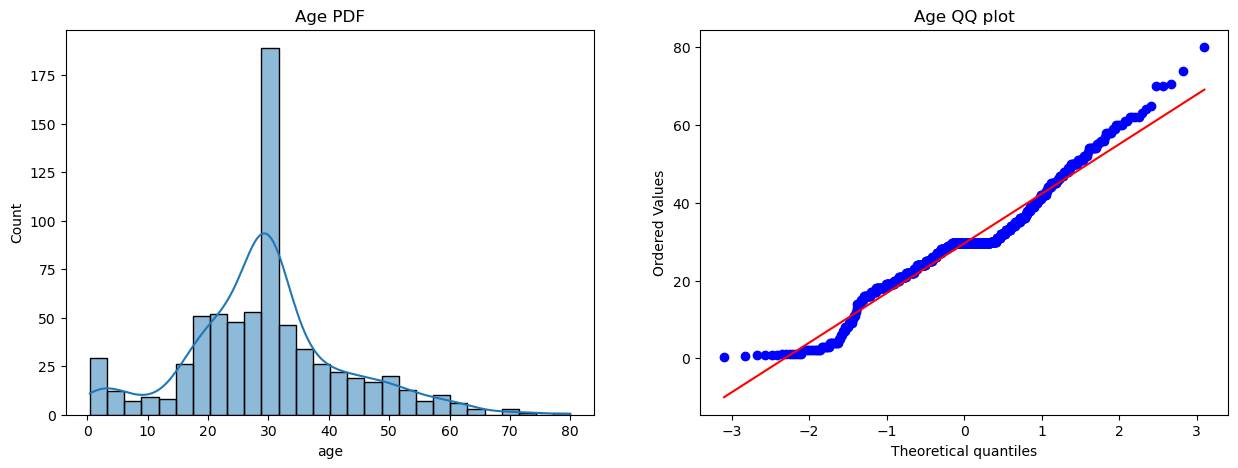

In [76]:
# to see the distribution of these two features ['fare', 'age']

plt.figure(figsize = (15,5))
plt.subplot(1, 2, 1)
sns.histplot(x_train['age'], kde = True)
plt.title('Age PDF')

plt.subplot(1, 2 , 2)
stats.probplot(x_train['age'], dist = 'norm', plot = plt)
plt.title('Age QQ plot')

plt.show()

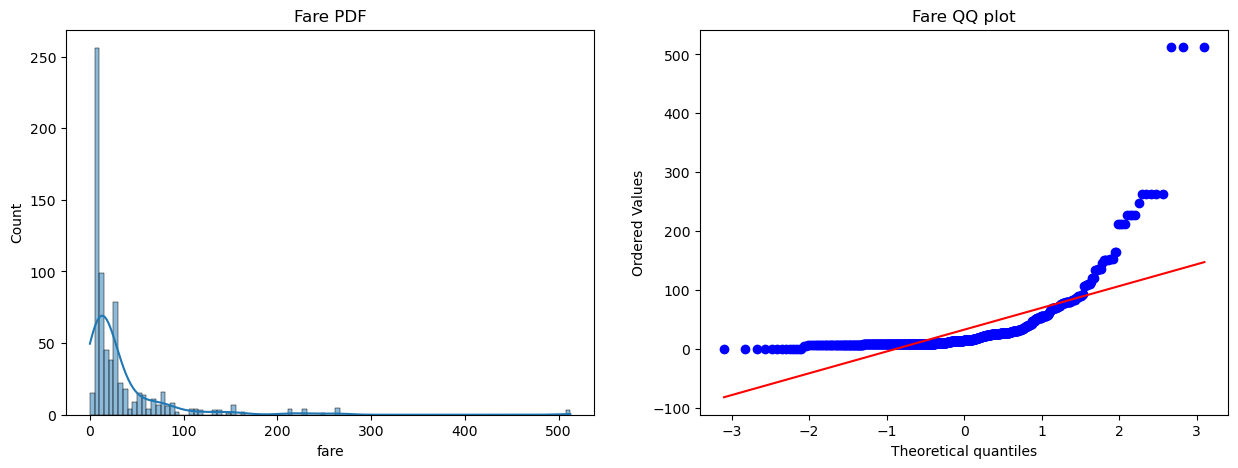

In [57]:
# now see the distribution of these two features ['fare']

plt.figure(figsize = (15,5))
plt.subplot(1, 2, 1)
sns.histplot(x_train['fare'], kde = True)
plt.title('Fare PDF')

plt.subplot(1, 2 , 2)
stats.probplot(x_train['fare'], dist = 'norm', plot = plt)
plt.title('Fare QQ plot')

plt.show()

In [77]:
# First train our model without any function transformation to check the accuracy 
lr = LogisticRegression()
dt = DecisionTreeClassifier()


In [78]:
lr.fit(x_train, y_train)
dt.fit(x_train, y_train)

lr_pred = lr.predict(x_test)
dt_pred = dt.predict(x_test)

# to see the accuracy of our model learn

print('LR Accuracy: ' , accuracy_score(y_test,lr_pred))
print('DT Accuracy: ', accuracy_score(y_test, dt_pred))

LR Accuracy:  0.6480446927374302
DT Accuracy:  0.6536312849162011


### Now try with Function Transformation:
- Becuase of our age column is normally distributed we can't transform it.

In [91]:
ft = FunctionTransformer(func = np.log1p)

In [92]:
x_train_transformed = ft.fit_transform(x_train)
x_test_transformed = ft.transform(x_test)


In [93]:
lr = LogisticRegression()
dt = DecisionTreeClassifier()

lr.fit(x_train_transformed, y_train)
dt.fit(x_train_transformed, y_train)

lr_pred = lr.predict(x_test_transformed)
dt_pred = dt.predict(x_test_transformed)

In [94]:
# checking accuracy of our learned model
print("LR Accuracy: ", accuracy_score(y_test, lr_pred))
print('DT Accuracy: ', accuracy_score(y_test, dt_pred))

LR Accuracy:  0.6815642458100558
DT Accuracy:  0.6871508379888268


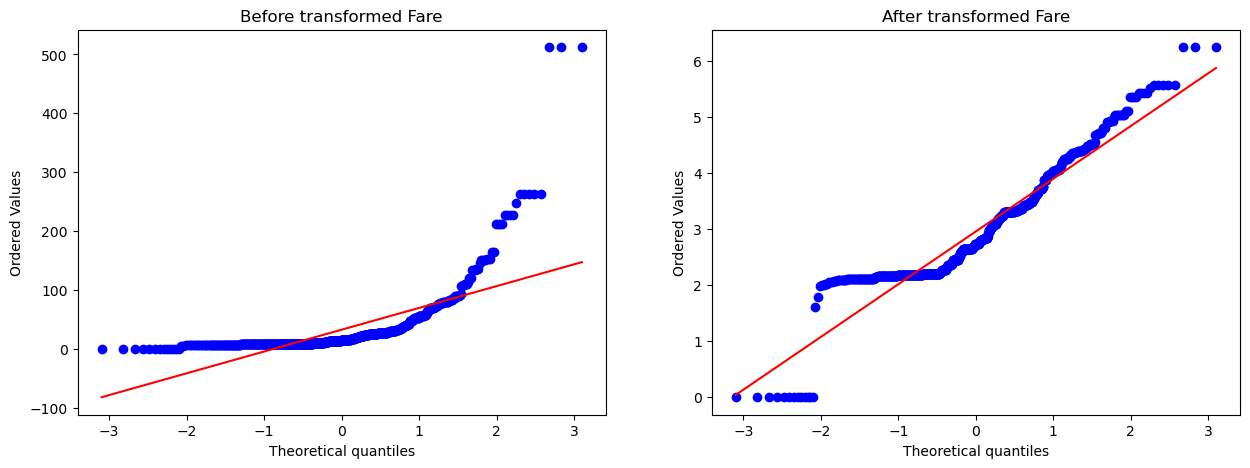

In [95]:
# to see visually to learned our model

plt.figure(figsize = (15, 5))
plt.subplot(1,2,1)
stats.probplot(x_train['fare'], dist = 'norm', plot = plt)
plt.title('Before transformed Fare')


plt.subplot(1,2,2)
stats.probplot(x_train_transformed['fare'], dist = 'norm', plot = plt)
plt.title('After transformed Fare')

plt.show()